<a href="https://colab.research.google.com/github/astinurin/Machine-Learning_2024/blob/Kuis-2/Kelompok_7_Machine_Learning_Kuis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kelompok 7

*   Asti Nurin Hidayanti (2241720236)
*   Ellois Karina Handoyo (2241720154)
*   Mohammad Naufal Syahandra(2241720189)
*   Rio Bagas Hermawan (2241720193)








In [ ]:
# KUIS 2 PEMBELAJARAN MESIN
Face Detection dan Face Recognition
# Intro

Pada kuis ini, Anda diminta untuk melakukan face detection dan face recognition pada wajah dengan menggunakan dataset primer (dataset wajah yang kalian kumpulkan sendiri).
Spesifikasi pengerjaan kuis yang harus dipehuni adalah,

1. Gunakan pre-trained model haarcascade_frontalface_default.xml untuk face detection
2. Gunakan pre-trained model faceNet untuk face recognition
3. Gunakan model CNN untuk face recognition

In [6]:
from google.colab import drive

drive.mount('/content/drive')

imagePath = '/content/drive/My Drive/Machine_Learning/kuis2/class1/foto_ktm_asti.jpg'

Mounted at /content/drive


## 1. Face Detection dengan haar cascade

Mengolah gambar: /content/drive/My Drive/Machine_Learning/kuis2/test/asti(c1).jpg
Jumlah wajah yang terdeteksi: 7


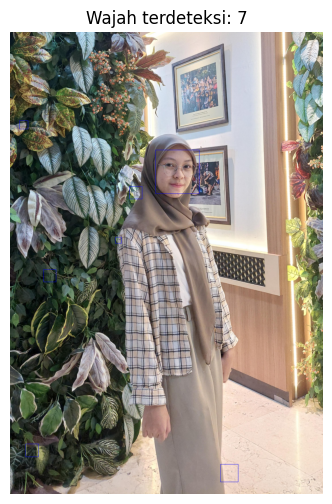

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path ke model Haar Cascade
face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"

# Muat model Haar Cascade
face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    raise FileNotFoundError("Model Haar Cascade tidak ditemukan.")

# Fungsi untuk mendeteksi wajah
def detect_faces(image_path):
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Gambar tidak dapat dibaca atau format tidak didukung: {image_path}")

    # Konversi ke grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Deteksi wajah
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Gambar kotak di sekitar wajah
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    return img, len(faces)

# Gambar yang akan diuji
image_paths = [
    "/content/drive/My Drive/Machine_Learning/kuis2/test/asti(c1).jpg"
]

# Deteksi wajah pada setiap gambar
for image_path in image_paths:
    print(f"Mengolah gambar: {image_path}")
    try:
        result_img, face_count = detect_faces(image_path)
        print(f"Jumlah wajah yang terdeteksi: {face_count}")

        # Tampilkan gambar dengan wajah yang terdeteksi
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Wajah terdeteksi: {face_count}")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"Error saat memproses gambar {image_path}: {e}")


## 2. pre-trained model faceNet untuk face recognition

In [17]:
!pip install keras opencv-python h5py numpy tensorflow

In [35]:
# Muat dan Ekstrak Wajah

import os
import cv2
import numpy as np

# Fungsi untuk ekstrak wajah menggunakan OpenCV
def extract_face(image_path):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    if len(faces) == 0:
        return None

    # Ambil wajah pertama yang terdeteksi
    x, y, w, h = faces[0]
    face = img[y:y+h, x:x+w]
    return face


In [36]:
# Membuat Model FaceNet

from tensorflow.keras.applications import MobileNetV2
from keras.layers import GlobalAveragePooling2D, Dense
from keras.models import Model

# Fungsi untuk membangun model FaceNet
def build_facenet_model(input_shape=(160, 160, 3)):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)  # Layer fully connected
    model = Model(inputs=base_model.input, outputs=x)
    model.summary()
    return model

# Bangun model FaceNet
facenet_model = build_facenet_model()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 160, 160, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 80, 80, 32)     │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 80, 80, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 80, 80, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 80, 80, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 80, 80, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 80, 80, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 80, 80, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 80, 80, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 80, 80, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 80, 80, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 80, 80, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 81, 81, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 40, 40, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,421,952 (9.24 MB)

 Trainable params: 2,387,840 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [37]:
# Fungsi untuk mendapatkan embeddings wajah menggunakan model FaceNet
def get_face_embeddings(model, face):
    """Menghasilkan embeddings wajah menggunakan model FaceNet"""
    face = cv2.resize(face, (160, 160))  # Sesuaikan dengan ukuran input model
    face = face / 255.0  # Normalisasi ke rentang [0, 1]
    face = np.expand_dims(face, axis=0)  # Tambahkan dimensi batch
    embedding = model.predict(face)  # Prediksi embeddings wajah
    return embedding

# Fungsi untuk menyiapkan dataset dan menyimpan embeddings ke file .h5
def prepare_and_save_dataset(dataset_path, model, output_file):
    embeddings_list = []
    labels = []

    # Label untuk masing-masing kelas
    label_dict = {'class1': 1, 'class2': 2, 'class3': 3, 'class4': 4}  # Ganti sesuai dengan kelas kamu

    for class_name, label in label_dict.items():
        class_path = os.path.join(dataset_path, class_name)

        # Periksa apakah folder class_path ada
        if not os.path.exists(class_path):
            print(f"Path tidak ditemukan: {class_path}")
            continue  # Lewati iterasi ini jika folder tidak ditemukan

        for filename in os.listdir(class_path):
            image_path = os.path.join(class_path, filename)  # Tentukan path gambar
            face = extract_face(image_path)  # Ekstraksi wajah dari gambar
            if face is not None:
                # Dapatkan embeddings dari wajah
                embeddings = get_face_embeddings(model, face)
                embeddings_list.append(embeddings)
                labels.append(label)

    # Konversi ke format numpy arrays
    embeddings_array = np.array(embeddings_list).squeeze()  # Menghilangkan dimensi ekstra
    labels_array = np.array(labels)

    # Simpan embeddings dan labels ke dalam file .h5
    with h5py.File(output_file, 'w') as hf:
        hf.create_dataset('embeddings', data=embeddings_array)
        hf.create_dataset('labels', data=labels_array)

    print(f"Dataset telah disimpan dalam {output_file}")

# Tentukan file output untuk menyimpan dataset dalam format .h5
output_file = '/content/drive/My Drive/Machine_Learning/kuis2/dataset.h5'
prepare_and_save_dataset('/content/drive/My Drive/Machine_Learning/kuis2/train', facenet_model, output_file)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━

In [39]:
# Simpan model FaceNet dalam format .keras
facenet_model.save('/content/drive/My Drive/Machine_Learning/kuis2/facenet_model.keras')
print("Model FaceNet telah disimpan dengan format .keras.")



Model FaceNet telah disimpan dengan format .keras.


In [67]:
# Fungsi untuk memuat dataset dari file .h5
def load_dataset_from_h5(file_path):
    with h5py.File(file_path, 'r') as hf:
        embeddings = np.array(hf['embeddings'])
        labels = np.array(hf['labels'])
    return embeddings, labels

# Muat dataset yang telah disimpan dalam file .h5
embeddings, labels = load_dataset_from_h5('/content/drive/My Drive/Machine_Learning/kuis2/dataset.h5')
print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")


Embeddings shape: (133, 128)
Labels shape: (133,)


Model FaceNet berhasil dimuat.
Embeddings shape: (133, 128)
Labels shape: (133,)

Mengolah gambar: /content/drive/My Drive/Machine_Learning/kuis2/test/soobin2.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Wajah dikenali sebagai: soobin (Similarity: 0.81)


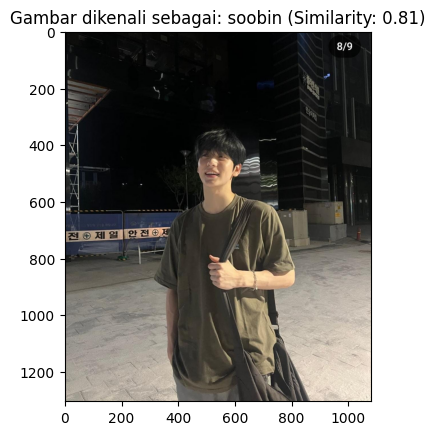


Mengolah gambar: /content/drive/My Drive/Machine_Learning/kuis2/test/naufal.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Wajah dikenali sebagai: naufal (Similarity: 0.76)


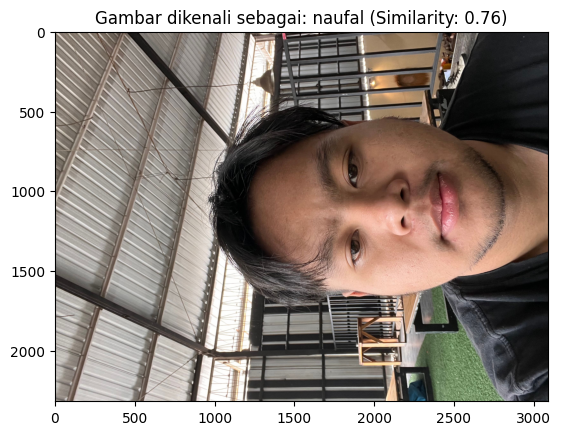


Mengolah gambar: /content/drive/My Drive/Machine_Learning/kuis2/test/asti(c1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Wajah dikenali sebagai: asti (Similarity: 0.74)


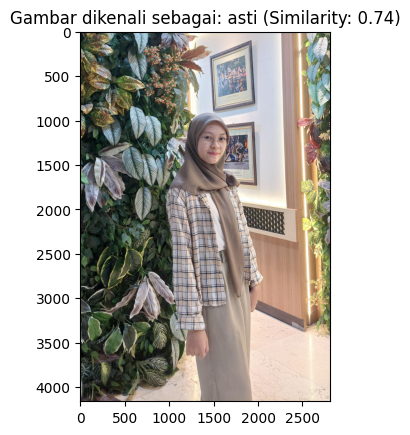

In [73]:
import numpy as np
import cv2
import os
import h5py
import matplotlib.pyplot as plt
from keras.models import load_model
from sklearn.metrics.pairwise import cosine_similarity

# Fungsi untuk membaca wajah baru dan mengekstrak embedding
def extract_face_embedding(image_path, model):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    # Periksa apakah file gambar ada
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Gambar tidak ditemukan di path: {image_path}")

    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Gambar tidak dapat dibaca atau format tidak didukung: {image_path}")

    # Konversi ke grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Deteksi wajah
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    if len(faces) == 0:
        raise ValueError("Tidak ada wajah yang terdeteksi dalam gambar.")

    # Ekstrak wajah pertama
    x, y, w, h = faces[0]
    face = img[y:y+h, x:x+w]

    # Resize dan normalisasi wajah
    face = cv2.resize(face, (160, 160))
    face = face / 255.0
    face = np.expand_dims(face, axis=0)

    # Prediksi embedding menggunakan model FaceNet
    embedding = model.predict(face)
    return embedding

# Fungsi untuk mengenali wajah berdasarkan database embeddings
def recognize_face(query_embedding, database_embeddings, labels, threshold=0.7):
    # Hitung kemiripan menggunakan Cosine Similarity
    similarities = cosine_similarity(query_embedding, database_embeddings)

    # Cari indeks wajah dengan kemiripan tertinggi
    max_similarity_idx = np.argmax(similarities)
    max_similarity = similarities[0][max_similarity_idx]

    if max_similarity > threshold:
        return int(labels[max_similarity_idx]), max_similarity
    else:
        return None, max_similarity

# Langkah 1: Muat model FaceNet
facenet_model_path = '/content/drive/My Drive/Machine_Learning/kuis2/facenet_model.keras'
if not os.path.exists(facenet_model_path):
    raise FileNotFoundError(f"Model FaceNet tidak ditemukan di path: {facenet_model_path}")
model_facenet = load_model(facenet_model_path)
print("Model FaceNet berhasil dimuat.")

# Langkah 2: Muat dataset embeddings dan labels
def load_dataset_from_h5(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset file tidak ditemukan di path: {file_path}")
    with h5py.File(file_path, 'r') as hf:
        embeddings = np.array(hf['embeddings'])
        labels = np.array(hf['labels'])
    return embeddings, labels

dataset_path = '/content/drive/My Drive/Machine_Learning/kuis2/dataset.h5'
embeddings, labels = load_dataset_from_h5(dataset_path)
print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")

# Langkah 3: Uji beberapa gambar
test_image_paths = [
    '/content/drive/My Drive/Machine_Learning/kuis2/test/soobin2.jpg',
    '/content/drive/My Drive/Machine_Learning/kuis2/test/naufal.jpeg',
    '/content/drive/My Drive/Machine_Learning/kuis2/test/asti(c1).jpg'
]  # Daftar path gambar untuk pengujian

class_mapping = {1: "asti", 2: "naufal", 3: "soobin", 4: "yeonjun"}  # Mapping kelas ke nama

for image_path in test_image_paths:
    print(f"\nMengolah gambar: {image_path}")
    try:
        # Ekstrak embedding
        query_embedding = extract_face_embedding(image_path, model_facenet)

        # Kenali wajah
        predicted_index, similarity = recognize_face(query_embedding, embeddings, labels, threshold=0.7)
        if predicted_index is not None:
            predicted_label = class_mapping.get(predicted_index, "Tidak Dikenali")
            print(f"Wajah dikenali sebagai: {predicted_label} (Similarity: {similarity:.2f})")
        else:
            print(f"Wajah tidak dikenali (Similarity: {similarity:.2f})")

        # Membaca gambar untuk ditampilkan
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Konversi ke RGB untuk ditampilkan dengan benar

        # Menampilkan gambar beserta keterangan
        plt.imshow(img)
        plt.title(f'Gambar dikenali sebagai: {predicted_label} (Similarity: {similarity:.2f})')
        plt.axis('on')
        plt.show()

    except Exception as e:
        print(f"Error saat memproses gambar {image_path}: {e}")


## 3. Model CNN untuk Face Recognition

In [38]:
# Melatih model CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Langkah 1: Persiapkan ImageDataGenerator untuk augmentasi dan pembacaan gambar
train_datagen = ImageDataGenerator(
    rescale=1./255,   # Normalisasi gambar
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    '/content/drive/My Drive/Machine_Learning/kuis2/train/',  # Path ke folder dataset
    target_size=(160, 160),  # Ukuran gambar yang ingin diubah
    batch_size=32,
    class_mode='categorical'  # Menggunakan klasifikasi multi-kelas
)

# Langkah 2: Membuat model CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(160, 160, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(len(train_generator.class_indices), activation='softmax')  # Jumlah kelas
])

# Langkah 3: Kompilasi model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Langkah 4: Melatih model CNN
model.fit(train_generator, epochs=20)

# Langkah 5: Menyimpan model terlatih
model.save('/content/drive/My Drive/Machine_Learning/kuis2/face_recognition_cnn.keras')

Found 157 images belonging to 4 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.2857 - loss: 1.3714
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.4122 - loss: 1.4068
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.4166 - loss: 1.3257
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.3921 - loss: 1.3244
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.4923 - loss: 1.2725
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5133 - loss: 1.2289
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5727 - loss: 1.1811
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5796 - loss: 1.1924
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.6004 - loss: 1.1167
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6058 - loss: 1.0780
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6238 - loss: 1.0326
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6107 - loss: 1.0358
Epoch 13/20
5/5 ━━━━━━━━

In [40]:
# Memuat model CNN yang sudah dilatih
model = tf.keras.models.load_model('/content/drive/My Drive/Machine_Learning/kuis2/face_recognition_cnn.keras')


In [41]:
# Persiapkan Gambar Uji (Test Images)

from tensorflow.keras.preprocessing import image
import numpy as np

# Fungsi untuk memproses gambar uji
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(160, 160))  # Ukuran gambar harus sesuai dengan input model
    img_array = image.img_to_array(img)  # Mengubah gambar menjadi array
    img_array = np.expand_dims(img_array, axis=0)  # Menambah dimensi batch
    img_array /= 255.0  # Normalisasi gambar (sama seperti di training)
    return img_array


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


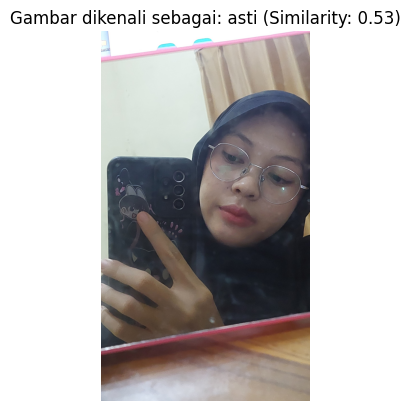

Gambar dikenali sebagai: asti (Similarity: 0.53)


In [66]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Fungsi untuk memuat dan memproses gambar
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Mengubah warna ke RGB untuk ditampilkan dengan benar
    img = cv2.resize(img, (160, 160))  # Sesuaikan ukuran gambar dengan input model
    img = img / 255.0  # Normalisasi
    img_array = np.expand_dims(img, axis=0)  # Tambah dimensi batch
    return img_array

# Predicted label mapping
class_labels = ['asti', 'naufal', 'soobin', 'yeonjun']  # Urutkan sesuai dengan index training

# Path gambar uji
test_image_path = '/content/drive/My Drive/Machine_Learning/kuis2/test/asti2.jpg'

# Memproses gambar uji
img_array = preprocess_image(test_image_path)

# Melakukan prediksi
predictions = model.predict(img_array)

# Menentukan kelas dengan probabilitas tertinggi
predicted_class = np.argmax(predictions, axis=1)[0]  # Ambil nilai index prediksi

# Menampilkan hasil prediksi
predicted_label = class_labels[predicted_class]  # Gunakan index untuk memilih label

# Membaca gambar untuk ditampilkan
img = cv2.imread(test_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Konversi ke RGB untuk ditampilkan dengan benar

# Menampilkan gambar beserta keterangan
plt.imshow(img)
plt.title(f'Gambar dikenali sebagai: {predicted_label} (Similarity: {predictions[0][predicted_class]:.2f})')
plt.axis('off')  # Menyembunyikan sumbu
plt.show()

# Print keterangan di console
print(f'Gambar dikenali sebagai: {predicted_label} (Similarity: {predictions[0][predicted_class]:.2f})')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


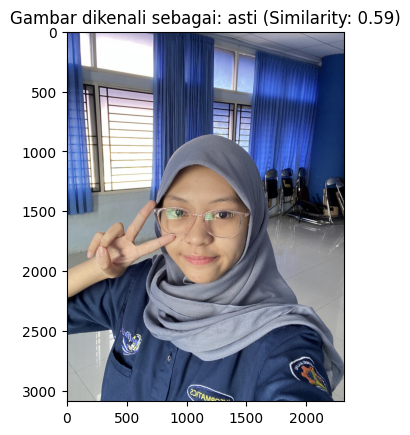

Gambar /content/drive/My Drive/Machine_Learning/kuis2/test/asti3.jpg dikenali sebagai: asti (Similarity: 0.59)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


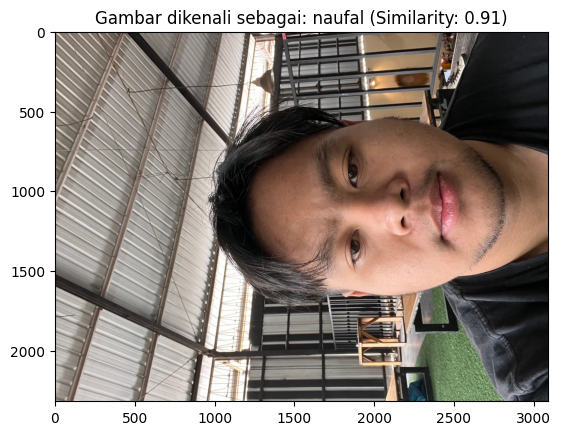

Gambar /content/drive/My Drive/Machine_Learning/kuis2/test/naufal.jpeg dikenali sebagai: naufal (Similarity: 0.91)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


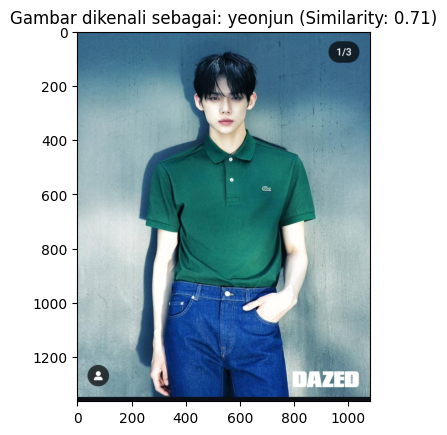

Gambar /content/drive/My Drive/Machine_Learning/kuis2/test/yeonjun.jpg dikenali sebagai: yeonjun (Similarity: 0.71)


In [62]:
import matplotlib.pyplot as plt
# Uji dengan Beberapa Gambar

# Contoh uji beberapa gambar
test_images = [
    '/content/drive/My Drive/Machine_Learning/kuis2/test/asti3.jpg',
    '/content/drive/My Drive/Machine_Learning/kuis2/test/naufal.jpeg',
    '/content/drive/My Drive/Machine_Learning/kuis2/test/yeonjun.jpg'
]

# Menampilkan gambar dan hasil prediksi
for img_path in test_images:
    # Proses gambar
    img_array = preprocess_image(img_path)

    # Prediksi menggunakan model
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)
    predicted_label = class_labels[predicted_class[0]]
    similarity = predictions[0][predicted_class[0]]  # Similarity score

    # Membaca gambar untuk ditampilkan
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Konversi ke RGB

    # Menampilkan gambar beserta keterangan
    plt.imshow(img)
    plt.title(f'Gambar dikenali sebagai: {predicted_label} (Similarity: {similarity:.2f})')
    plt.axis('off')  # Menyembunyikan sumbu
    plt.show()

    # Print keterangan di console
    print(f'Gambar {img_path} dikenali sebagai: {predicted_label} (Similarity: {similarity:.2f})')
